# Delivery time prediction

Regression on 96,470 delivered orders. Target is delivery_days, split is
time-based, metric is MAE. The bar is a per-state median.

Section 14 turns the prediction into a promise and checks whether a better MAE
buys a shorter one.

## 1. Data preparation

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
import joblib
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
import numpy as np
import json

plt.style.use('default')
plt.rcParams.update({
    'figure.facecolor': 'white',
    'savefig.facecolor': 'white',
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
    'axes.grid': True,
    'grid.alpha': 0.3,
})

clean = pd.read_parquet("../data/clean/clean.parquet")
print(clean.shape)

(96470, 37)


## 2. Time-based split

In [2]:
TRIM = 60
TARGET = 'delivery_days'

clean = clean.sort_values('order_purchase_timestamp').reset_index(drop=True)

split_point = int(len(clean) * 0.8)
val_point = int(split_point * 0.85)

train_full = clean.iloc[:split_point]
test = clean.iloc[split_point:]
val = train_full.iloc[val_point:]

In [3]:
print("Train full:", len(train_full))
print("Val:", len(val), "(no trim)")
print("Test:", len(test), "(no trim)")
print("Val from:", val['order_purchase_timestamp'].min())
print("Test from:", test['order_purchase_timestamp'].min())
print("Test until:", test['order_purchase_timestamp'].max())
print("Orders >= 60 days in test:", (test[TARGET] >= TRIM).sum())

Train full: 77176
Val: 11577 (no trim)
Test: 19294 (no trim)
Val from: 2018-04-06 11:17:17
Test from: 2018-05-26 18:18:03
Test until: 2018-08-29 15:00:37
Orders >= 60 days in test: 14


Time-based split on 96,470 orders: train 77,176 (until 2018-05-26), test 19,294
(late May–Aug 2018). Validation is the last 15% of train, 11,577 orders from April
to May. The 60-day trim is applied only where the model is fitted; validation and
test keep the full tail, the way production would see it. 14 orders in test take
60+ days and stay there. All decisions are made on validation. Test is used once,
at the end. Test covers the fastest period of the year, no winter months.

In [4]:
cat_cols = ['customer_state', 'seller_state', 'product_category_name']

train_core_raw = clean.iloc[:val_point]
train_core_idx = train_core_raw.index[train_core_raw[TARGET] < TRIM]

for col in cat_cols:
    cats = clean.loc[train_core_idx, col].astype('category').cat.categories
    codes = pd.Categorical(clean[col], categories=cats).codes.astype('float64')
    codes[codes == -1] = np.nan
    clean[col + '_code'] = codes

print("Unknown categories:", clean[[c + '_code' for c in cat_cols]].isnull().sum().sum())

Unknown categories: 13


/var/folders/b6/cybybv717ml8j8jhjn20_p5m0000gn/T/ipykernel_1906/1197205345.py:8: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  codes = pd.Categorical(clean[col], categories=cats).codes.astype('float64')


In [5]:
clean['distance_missing'] = clean['distance_km'].isnull().astype(int)
print("Orders with no usable coordinates:", clean['distance_missing'].sum())

Orders with no usable coordinates: 477


Orders with no zip-code coordinates get the training median. That is a strong assumption
for an unknown location, so the fact that a value was imputed is kept as its own column.

In [6]:
num_fill = ['total_weight_g', 'total_volume_cm3',
            'max_length_cm', 'max_height_cm', 'max_width_cm', 'distance_km']

medians = clean.loc[train_core_idx, num_fill].median()
clean[num_fill] = clean[num_fill].fillna(medians)

print("NaN left:", clean[num_fill].isnull().sum().sum())

NaN left: 0


In [7]:
train_full = clean.iloc[:split_point]
test = clean.iloc[split_point:]
val = train_full.iloc[val_point:]

train_core = clean.loc[train_core_idx]
train_fit = train_full[train_full[TARGET] < TRIM]

print("Train core:", len(train_core))
print("Train fit:", len(train_fit))

Train core: 65328
Train fit: 76884


Preprocessing after the split: category codes and medians are fitted on train_core
only. Categories unseen in training become NaN, which HistGradientBoosting treats as
a missing category rather than as a value below all others.

## 3. Baselines on validation

In [8]:
def baselines(fit_df, eval_df):
    naive = fit_df[TARGET].mean()
    mae_naive = (eval_df[TARGET] - naive).abs().mean()

    state_med  = fit_df.groupby('customer_state')[TARGET].median()
    global_med = fit_df[TARGET].median()
    pred_state = eval_df['customer_state'].map(state_med).fillna(global_med)
    mae_state  = (eval_df[TARGET] - pred_state).abs().mean()

    mae_olist = (eval_df['estimated_days'] - eval_df[TARGET]).abs().mean()
    return mae_naive, mae_state, mae_olist

In [9]:
mae_naive_val, mae_state_val, mae_olist_val = baselines(train_core, val)
print(f"Naive mean (val): {mae_naive_val:.3f}")
print(f"Per-state median: {mae_state_val:.3f}")
print(f"Olist estimate (val): {mae_olist_val:.3f}")

Naive mean (val): 6.653
Per-state median: 4.879
Olist estimate (val): 13.258


Baselines on validation: naive mean 6.65, per-state median 4.88, Olist estimate 13.26.
Seasonal drift between train and val inflates the naive mean.

The per-state median is the bar that counts. Geography carries most of the signal, and a
single number that ignores it is easy to beat. Anything that does not clear 4.88 adds
nothing over a groupby.

## 4. RandomForest

In [10]:
FEATURES = ['purchase_month', 'purchase_day_of_week', 'purchase_year',
            'total_price', 'total_freight', 'quantity_items', 'same_state', 'total_weight_g',
            'total_volume_cm3', 'customer_state_code', 'seller_state_code', 'product_category_name_code']

print("Missing: ", [c for c in FEATURES if c not in clean.columns])

Missing:  []


RandomForest cannot accept NaN, so unknown categories are filled with -1 for this model
only.

In [11]:
X_train = train_core[FEATURES].fillna(-1)
Y_train = train_core[TARGET]
X_val   = val[FEATURES].fillna(-1)
Y_val   = val[TARGET]

print(X_train.shape, X_val.shape)

(65328, 12) (11577, 12)


In [12]:
model_rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model_rf.fit(X_train, Y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [13]:
pred = model_rf.predict(X_val)

mae_model_rf = mean_absolute_error(Y_val, pred)
r2_model_rf = r2_score(Y_val, pred)

print("R2 score Random Forest: ", r2_model_rf)
print("MAE score Random Forest: ", mae_model_rf)
print("MAE naive (val): ", mae_naive_val)
print("MAE Olist (val): ", mae_olist_val)

R2 score Random Forest:  0.20156742755764745
MAE score Random Forest:  5.268052415579579
MAE naive (val):  6.653044326739395
MAE Olist (val):  13.257669385179426


## 5. Error analysis

In [14]:
errors_rf = (Y_val - pred).abs()
print(errors_rf.describe().round(2))
print("Errors > 15 days:", (errors_rf > 15).sum())

count    11577.00
mean         5.27
std          5.16
min          0.00
25%          2.00
50%          4.07
75%          7.12
max        125.50
Name: delivery_days, dtype: float64
Errors > 15 days: 409


RandomForest MAE 5.27, behind the per-state median at 4.88. Median error 4.07, 75% within
7.12. But 409 orders (3.5%) miss by more than 15 days and the worst case is 125.

R2 is 0.20. It squares the errors, so the few 60+ day orders dominate it. MAE stays the
primary metric.

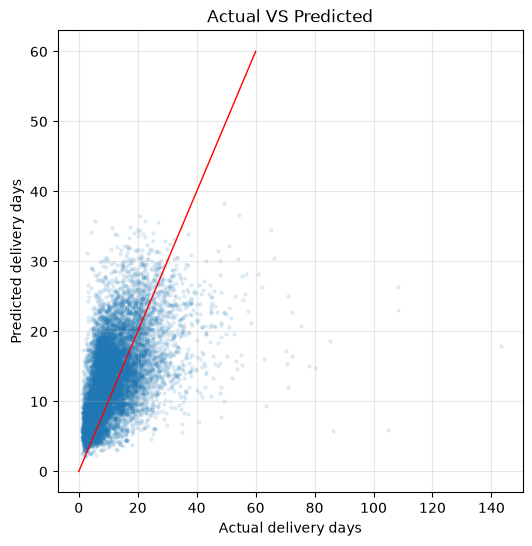

In [15]:
plt.figure(figsize=(6, 6))
plt.scatter(Y_val, pred, alpha=0.1, s = 5)
plt.plot([0,60],[0,60], color='Red', linewidth = 1)
plt.xlabel("Actual delivery days")
plt.ylabel("Predicted delivery days")
plt.title("Actual VS Predicted")
plt.show()

Typical deliveries sit on the diagonal. Delays of 30+ days come out as 10 to 20. The model
does not see them coming.

## 6. Feature importances

In [16]:
importances = pd.Series(model_rf.feature_importances_, index=FEATURES).sort_values(ascending=False)
print(importances.round(3))

same_state                    0.159
total_freight                 0.134
total_price                   0.118
total_volume_cm3              0.113
total_weight_g                0.105
customer_state_code           0.095
product_category_name_code    0.072
purchase_month                0.071
purchase_day_of_week          0.069
purchase_year                 0.030
seller_state_code             0.025
quantity_items                0.009
dtype: float64


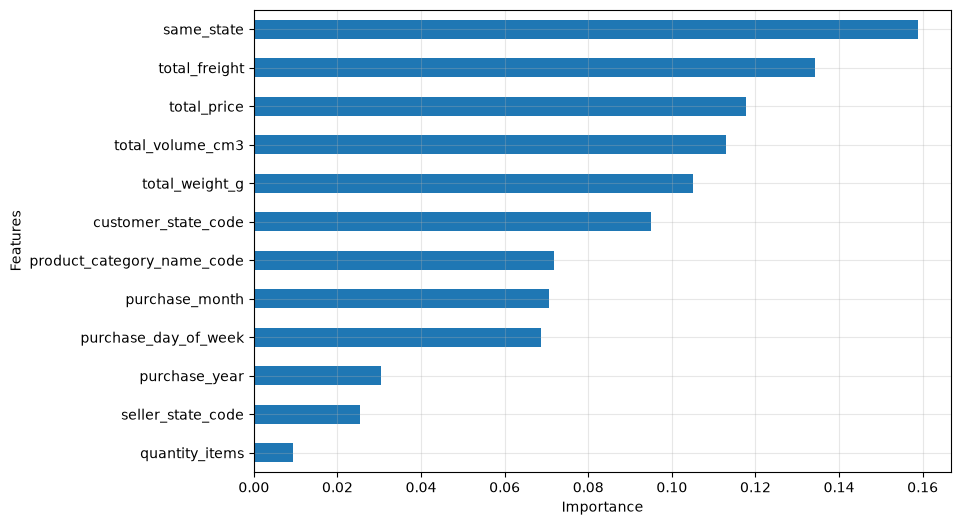

In [17]:
importances.sort_values().plot.barh(figsize=(9, 6))
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()

## 7. Feature ablation

Checking whether the weakest features by importance contribute to MAE or just add noise.

In [18]:
DROP = ['seller_state_code', 'purchase_year', 'quantity_items']

FEATURES_SLIM = [f for f in FEATURES if f not in DROP]

model_rf_slim = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model_rf_slim.fit(train_core[FEATURES_SLIM].fillna(-1), Y_train)
pred_rf_slim = model_rf_slim.predict(val[FEATURES_SLIM].fillna(-1))

print("Features: ", len(FEATURES_SLIM))
print("MAE slim: ", round(mean_absolute_error(Y_val, pred_rf_slim), 3))
print("MAE full: ", round(mae_model_rf, 3))

Features:  9
MAE slim:  5.099
MAE full:  5.268


Dropped the three weakest features by importance. Validation MAE improved from 5.27 to 5.09.

purchase_year was never going to work. Under a time-based split the test period always falls
in a year the model has never seen, and a tree cannot extrapolate past its training range.
The ablation confirms it.

RandomForest at 5.09 still loses to the per-state median at 4.88. Nine features in a tree
ensemble add nothing over a groupby while the loss and the metric disagree.

## 8. HistGradientBoosting

In [19]:
HGB_PARAMS = dict(loss='absolute_error', random_state=42)

model_hgb = HistGradientBoostingRegressor(**HGB_PARAMS)
model_hgb.fit(train_core[FEATURES_SLIM], Y_train)
pred_hgb = model_hgb.predict(val[FEATURES_SLIM])

print("MAE HGB slim: ", mean_absolute_error(Y_val, pred_hgb))
print("MAE RF slim: ", mean_absolute_error(Y_val, pred_rf_slim))

MAE HGB slim:  4.518019166111492
MAE RF slim:  5.099043078315394


In [20]:
model_hgb_sq = HistGradientBoostingRegressor(loss='squared_error', random_state=42)
model_hgb_sq.fit(train_core[FEATURES_SLIM], Y_train)
mae_hgb_sq = mean_absolute_error(Y_val, model_hgb_sq.predict(val[FEATURES_SLIM]))

print(f"RF slim,  squared: {mean_absolute_error(Y_val, pred_rf_slim):.3f}")
print(f"HGB slim, squared: {mae_hgb_sq:.3f}")
print(f"HGB slim, absolute: {mean_absolute_error(Y_val, pred_hgb):.3f}")

RF slim,  squared: 5.099
HGB slim, squared: 4.857
HGB slim, absolute: 4.518


In [21]:
print("R2: ", r2_score(Y_val, pred_hgb))

errors_hgb = round((Y_val - pred_hgb).abs(), 3)
print("Errors > 15: ", (errors_hgb > 15).sum())

R2:  0.2737228800134359
Errors > 15:  455


Same 9 features, three configurations: RandomForest 5.099, HGB with squared_error 4.857, HGB with absolute_error 4.518. The largest single gain in the project. Switching to boosting accounts for 0.24 days of it, matching the loss to the metric for 0.34.

There is a trade-off. HGB has more large misses, 455 against 409 over 15 days, on a lower MAE. Absolute error stops the model chasing the long tail and lets it fit the typical order.

## 9. Distance feature

In [22]:
FEATURES_GEO = FEATURES_SLIM + ['distance_km', 'distance_missing']

In [23]:
model_hgb_geo = HistGradientBoostingRegressor(**HGB_PARAMS)
model_hgb_geo.fit(train_core[FEATURES_GEO], Y_train)
pred_hgb_geo = model_hgb_geo.predict(val[FEATURES_GEO])

print("MAE HGB slim + geo: ", mean_absolute_error(Y_val, pred_hgb_geo))
print("MAE HGB slim: ", mean_absolute_error(Y_val, pred_hgb))

MAE HGB slim + geo:  4.379023539618274
MAE HGB slim:  4.518019166111492


distance_km and distance_missing added: MAE 4.52 to 4.37 on validation. Haversine between
zip centroids carries geographic signal that state and freight alone miss.

The missing flag touches 477 orders out of 77k, so on its own it changes almost nothing. It
lets the model tell a filled-in distance from a real one.

## 10. Ablation re-check

The ablation in section 7 ran before distance_km existed. Geography is now represented
directly, so features that looked redundant next to customer_state may behave differently.
Adding each dropped feature back, one at a time, on the final feature set.

In [24]:
base_mae = mean_absolute_error(Y_val, pred_hgb_geo)

In [25]:
print("Base:", round(base_mae, 3))

for f in ['seller_state_code', 'purchase_year', 'quantity_items']:
    trial = FEATURES_GEO + [f]
    m = HistGradientBoostingRegressor(**HGB_PARAMS)
    m.fit(train_core[trial], Y_train)
    print(f"{f}:", round(mean_absolute_error(Y_val, m.predict(val[trial])), 3))

Base: 4.379
seller_state_code: 4.374
purchase_year: 4.35
quantity_items: 4.36


None of the three is worth adding back. All of them land within 0.03 days of the base model, which is too small to act on. The section 7 decision still holds.

## 11. Olist's estimate as a feature

estimated_days is known at checkout, so using it is not leakage. The estimate knows the
route, the carrier and the delivery zone. None of that is in the public order tables. If it
helps the model, that gap is real.

In [26]:
FEATURES_EST = FEATURES_GEO + ['estimated_days']

m = HistGradientBoostingRegressor(**HGB_PARAMS)
m.fit(train_core[FEATURES_EST], Y_train)
pred_est = m.predict(val[FEATURES_EST])

print("With estimate:", round(mean_absolute_error(Y_val, pred_est), 3))
print("Without:", round(base_mae, 3))

With estimate: 4.36
Without: 4.379


Almost nothing: 4.36 against 4.38. Olist's estimate is built on routing data that is not
in the public tables, but state, seller state and haversine distance already carry the same
information. The estimate is left out of the final model so it stays a clean baseline.

## 12. Hyperparameter tuning

In [27]:
param_grid ={
    'max_iter': [100, 300],
    'learning_rate': [0.05, 0.1],
    'max_depth': [None, 6]
}

tscv = TimeSeriesSplit(n_splits=3, test_size=5000)

grid = GridSearchCV(
    HistGradientBoostingRegressor(**HGB_PARAMS),
    param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

grid.fit(train_core[FEATURES_GEO], train_core[TARGET])

print("Best params: ", grid.best_params_)
print("Best CV MAE: ", round(-grid.best_score_, 3))

Best params:  {'learning_rate': 0.1, 'max_depth': None, 'max_iter': 300}
Best CV MAE:  6.543


In [28]:
model_tuned_val = HistGradientBoostingRegressor(**grid.best_params_, **HGB_PARAMS)
model_tuned_val.fit(train_core[FEATURES_GEO], train_core[TARGET])
pred_tuned_val = model_tuned_val.predict(val[FEATURES_GEO])

print("MAE tuned (val): ", round(mean_absolute_error(Y_val, pred_tuned_val), 3))
print("MAE default (val):", round(mean_absolute_error(Y_val, pred_hgb_geo), 3))

MAE tuned (val):  4.384
MAE default (val): 4.379


GridSearch with TimeSeriesSplit inside train_core, so validation stays independent. Best
params: lr 0.1, depth None, 300 iterations.

On validation the tuned model comes out slightly worse than the default, 4.384 against 4.379. The difference is noise, but tuning did not help. The tuned config is kept because it
was selected without looking at validation.

CV MAE 6.53 is not comparable to validation. The folds fall in the slow season and the
earliest one trains on much less data.

## 13. Final evaluation on test

Test is untouched until here. The model is refit on training data through May 2018 and
scored once. Section 14 opens it again to turn that score into a promise, and marks where
that crosses into looking at test.

In [29]:
final_model = HistGradientBoostingRegressor(**grid.best_params_, **HGB_PARAMS)
final_model.fit(train_fit[FEATURES_GEO], train_fit[TARGET])
pred_final = final_model.predict(test[FEATURES_GEO])

print("MAE test (final):", round(mean_absolute_error(test[TARGET], pred_final), 3))
print("R2 test (final):", round(r2_score(test[TARGET], pred_final), 3))

MAE test (final): 3.55
R2 test (final): 0.231


In [30]:
err = (test[TARGET] - pred_final).abs()

print(err.describe().round(2).to_string())
print(f"\nErrors > 15 days: {(err > 15).sum()} ({(err > 15).mean()*100:.1f}%)")
print(f"Bias: {(pred_final - test[TARGET]).mean():+.2f} days")

by_state = (pd.DataFrame({'state': test['customer_state'], 'err': err})
            .groupby('state')['err'].agg(['mean', 'count'])
            .query('count >= 100').sort_values('mean', ascending=False))
print("\nWorst states:\n", by_state.head(5).round(2).to_string())

count    19294.00
mean         3.55
std          3.77
min          0.00
25%          1.32
50%          2.82
75%          4.76
max        122.29

Errors > 15 days: 242 (1.3%)
Bias: +1.08 days

Worst states:
        mean  count
state             
BA     6.20    638
PA     6.05    159
PE     6.04    322
PB     5.78    113
MA     5.10    115


Final model on test: median error 2.82 days, 75% within 4.76. 242 orders (1.3%) miss by more
than 15 days, worst case 122.

Bias is +1.08 days. The model overpredicts because train covers slower months than test and
it carries the old pace into a faster season.

Worst states are BA, PA, PE, PB, MA at 5.1 to 6.2. All North and Northeast, the same
geography that dominates the EDA.

In [31]:
mae_naive, mae_state, mae_olist = baselines(train_fit, test)
mae_final = mean_absolute_error(test[TARGET], pred_final)

print(f"Naive mean: {mae_naive:.2f}")
print(f"Per-state median: {mae_state:.2f}")
print(f"Olist estimate: {mae_olist:.2f}")
print(f"Final model: {mae_final:.2f}")
print(f"\nGain vs naive: {(1 - mae_final/mae_naive)*100:.1f}%")
print(f"Gain vs state: {(1 - mae_final/mae_state)*100:.1f}%")

Naive mean: 6.23
Per-state median: 4.42
Olist estimate: 14.04
Final model: 3.55

Gain vs naive: 43.0%
Gain vs state: 19.6%


In [32]:
preds = {}

m = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
m.fit(train_fit[FEATURES_SLIM].fillna(-1), train_fit[TARGET])
preds['RF, 9 features'] = m.predict(test[FEATURES_SLIM].fillna(-1))

m = HistGradientBoostingRegressor(**HGB_PARAMS)
m.fit(train_fit[FEATURES_SLIM], train_fit[TARGET])
preds['HGB'] = m.predict(test[FEATURES_SLIM])

m = HistGradientBoostingRegressor(**HGB_PARAMS)
m.fit(train_fit[FEATURES_GEO], train_fit[TARGET])
preds['HGB + distance'] = m.predict(test[FEATURES_GEO])

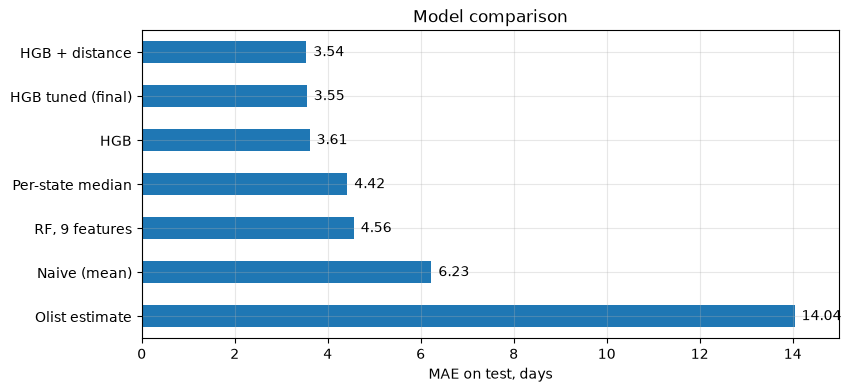

In [33]:
results = pd.Series({
    'Olist estimate': round(mae_olist, 2),
    'Naive (mean)': round(mae_naive, 2),
    'Per-state median': round(mae_state, 2),
    **{name: round(mean_absolute_error(test[TARGET], p), 2) for name, p in preds.items()},
    'HGB tuned (final)': round(mean_absolute_error(test[TARGET], pred_final), 2),
}).sort_values(ascending=False)

ax = results.plot.barh(figsize=(9, 4))
for i, v in enumerate(results):
    ax.text(v + 0.15, i, str(v), va='center')

plt.xlim(0, 15)
plt.xlabel("MAE on test, days")
plt.title("Model comparison")
plt.savefig('../images/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

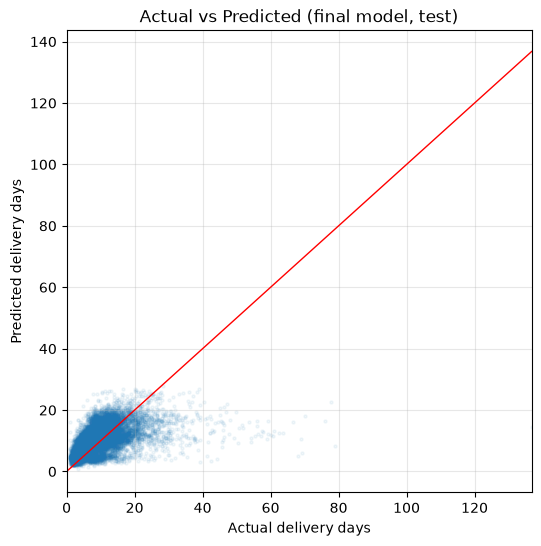

In [34]:
plt.figure(figsize=(6, 6))
plt.scatter(test[TARGET], pred_final, alpha=0.06, s=5)
lim = test[TARGET].max()
plt.plot([0, lim], [0, lim], color='red', linewidth=1)
plt.xlim(0, lim)
plt.xlabel("Actual delivery days")
plt.ylabel("Predicted delivery days")
plt.title("Actual vs Predicted (final model, test)")
plt.savefig('../images/actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

In [35]:
joblib.dump(final_model, "../models/hgb_final.joblib")
joblib.dump(FEATURES_GEO, "../models/features.joblib")

mappings = {}
for col in cat_cols:
    cats = clean.loc[train_core_idx, col].astype('category').cat.categories
    mappings[col] = {str(c): i for i, c in enumerate(cats)}

with open("../models/category_mappings.json", "w") as f:
    json.dump(mappings, f)

medians.to_json("../models/num_medians.json")

print("Saved model, features, mappings, medians")

Saved model, features, mappings, medians


The model file is not enough on its own. Category codes and fill medians are
built from train_core here, so they have to be saved next to the model. If the
service works them out from its own data, SP might get code 0 here and code 3
there. Nothing errors, the numbers just come out wrong.

## 14. What a model-based promise would look like

A prediction lands in the middle of the distribution, so half the orders arrive later than
it says. A promise needs a margin on top.

The margin is a quantile of validation residuals. Setting it so the model misses as often as
Olist does makes the two comparable.

In [36]:
resid_val = val[TARGET] - model_tuned_val.predict(val[FEATURES_GEO])
print(resid_val.describe().round(2))

count    11577.00
mean         0.95
std          6.83
min        -18.16
25%         -2.98
50%         -0.72
75%          3.14
max        132.93
Name: delivery_days, dtype: float64


These residuals come from the model fit on train_core, so validation data was not used
in training.

In [37]:
olist_on_time = (test[TARGET] <= test['estimated_days']).mean()
print(f"Olist on-time: {olist_on_time:.3f}")

Olist on-time: 0.965


This is 96.5%, but notebook 01 says 93.2%. The test window is in the fast season, so Olist
misses less often here than over the full period.

In [38]:
q = resid_val.quantile(olist_on_time)
promise_flat = pred_final + q

print(f"Margin: {q:.1f} days")
print(f"On-time: {(test[TARGET] <= promise_flat).mean():.3f}")
print(f"Model promise: {promise_flat.mean():.1f} days")
print(f"Olist promise: {test['estimated_days'].mean():.1f} days")

Margin: 15.6 days
On-time: 0.988
Model promise: 25.4 days
Olist promise: 22.4 days


One margin for everything does not work. The promise comes out at 25.4 days, longer than
Olist's 22.4. And it is too safe: 98.8% on time instead of the 96.5% we aimed for.

Three reasons. Validation is April and May, test is summer. Every state gets the
same margin. And the residuals come from model_tuned_val, fitted on train_core,
while the predictions come from final_model, fitted on the larger train_fit. The weaker model misses by more, so the margin comes out too big.

In [39]:
resid_test = test[TARGET] - pred_final

for lvl in [0.90, 0.95, 0.965, 0.99]:
    print(f"{lvl}: val {resid_val.quantile(lvl):.1f}, test {resid_test.quantile(lvl):.1f}")

0.9: val 8.8, test 4.0
0.95: val 12.7, test 7.0
0.965: val 15.6, test 8.5
0.99: val 25.0, test 17.0


The tail on test is half as wide, 8.5 days against 15.6. Validation is a slower season, so
the margin brought from there is too big.

Test residuals here are diagnostic. Nothing in the calibration uses them.

In [40]:
resid_by_state = (pd.DataFrame({'state': val['customer_state'].values,
                                'resid': resid_val.values})
    .groupby('state')['resid']
    .agg(n='size', margin=lambda s: s.quantile(olist_on_time))
    .query('n >= 100')
    .sort_values('margin'))

print(resid_by_state.round(1).to_string())

          n  margin
state              
SP     5228    10.2
DF      249    12.0
MT      115    12.5
GO      232    12.6
MG     1323    13.6
SC      411    14.2
PR      585    14.8
RS      596    15.2
RJ     1397    19.3
ES      226    20.3
BA      376    23.0
PE      179    26.7
CE      143    30.7


Margins run from 10.2 days in SP to 30.7 in CE, so one number cannot serve both.

In [41]:
def state_margins(level):
    return (pd.DataFrame({'state': val['customer_state'].values, 'resid': resid_val.values})
            .groupby('state')['resid'].agg(n='size', q=lambda s: s.quantile(level))
            .query('n >= 100')['q'])

LEVEL = olist_on_time

margins = state_margins(LEVEL)
promise_model = pred_final + test['customer_state'].map(margins).fillna(
    resid_val.quantile(LEVEL)).values

print(f"On-time, model: {(test[TARGET] <= promise_model).mean():.3f}")
print(f"On-time, Olist: {olist_on_time:.3f}")
print(f"Promise, model: {promise_model.mean():.1f} days")
print(f"Promise, Olist: {test['estimated_days'].mean():.1f} days")

On-time, model: 0.985
On-time, Olist: 0.965
Promise, model: 23.5 days
Promise, Olist: 22.4 days


In [42]:
margins_out = margins.to_dict()
margins_out['_global'] = float(resid_val.quantile(LEVEL))

json.dump(margins_out, open("../models/state_margins.json", "w"))
print("Saved state margins:", len(margins), "states, global fallback",
      round(margins_out['_global'], 1))

Saved state margins: 13 states, global fallback 15.6


Per-state margins bring the promise down to 23.5 days from 25.4. Still longer than Olist's
22.4, but on time more often, 98.5% against 96.5%.

In [43]:
for lvl in [0.85, 0.90, 0.93, olist_on_time]:
    m = test['customer_state'].map(state_margins(lvl)).fillna(resid_val.quantile(lvl))
    p = pred_final + m.values
    print(f"target {lvl:.3f}: on-time {(test[TARGET] <= p).mean():.3f}, "
          f"promise {p.mean():.1f}, vs Olist {p.mean() - test['estimated_days'].mean():+.1f}")

target 0.850: on-time 0.927, promise 15.8, vs Olist -6.6
target 0.900: on-time 0.954, promise 18.0, vs Olist -4.4
target 0.930: on-time 0.970, promise 19.8, vs Olist -2.6
target 0.965: on-time 0.985, promise 23.5, vs Olist +1.2


States with fewer than 100 validation orders fall back to the global margin.

The margin from validation is too big for the test season. We asked for 96.5% on time and
got 98.5%. Ask for 93% and the promise drops to 19.8 days, under Olist. But 93% was picked
by looking at test, so it is not a result.

A good MAE does not buy a short promise. The margin has to cover the worst orders, and in CE the validation residuals need 30 days while SP needs 10. Any real version of this would set the margin per
route and redo it every season.

## Summary

The model predicts better but does not promise better: 23.5 days against Olist's
22.4 at the same on-time rate. The promise is set by the worst orders, and those
stay unpredictable.

Geography does most of the work. A per-state median gets MAE 4.42, the full model
3.55. Ten features on top of customer_state buy 20% over a groupby.

R2 is 0.23 and the model overpredicts by 1.08 days after learning on slower months.
Production would need refitting on a rolling window.